In [ ]:
# imports
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from dotenv import load_dotenv

In [ ]:
# load dataset from Kaggle
load_dotenv()
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

# read all CSV files in the dataset directory, create df
csv_files = glob.glob(os.path.join(path, "*.csv"))
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# clean up column names
df.columns = df.columns.str.strip()

# clean up label names
df['Label'] = df['Label'].str.replace(r'\s+', ' ', regex=True).str.strip()

# drop rows with missing or infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Shape: {df.shape}")

Shape: (2827876, 79)


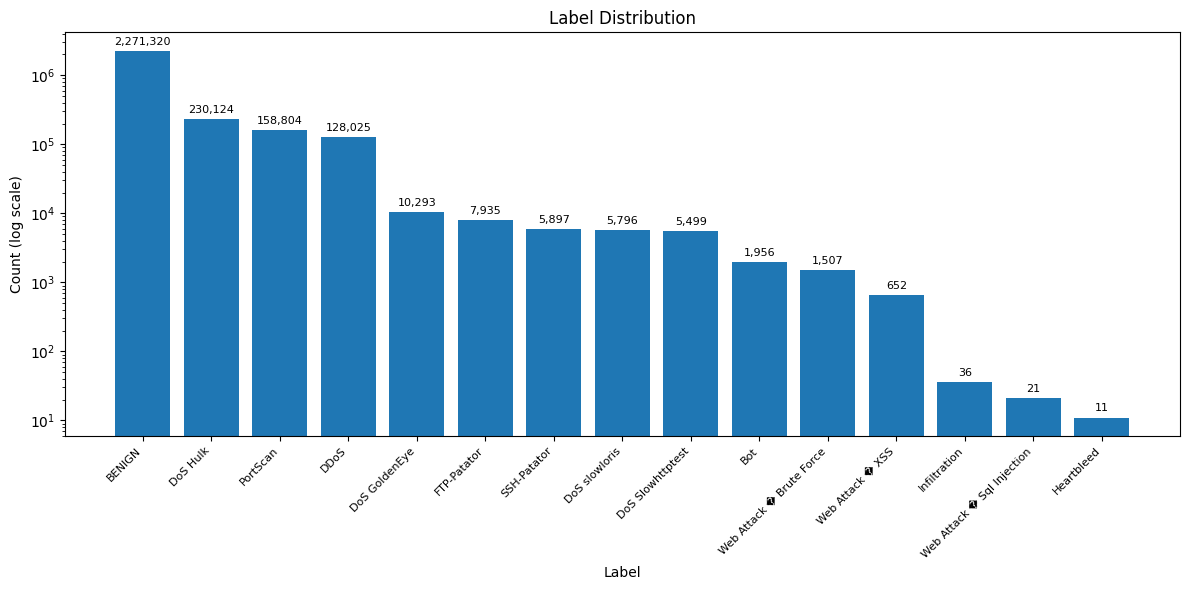

In [ ]:
# plot label distribution
label_counts = df['Label'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(label_counts.index, label_counts.values)
ax.set_yscale('log') # log scale since the benign class is so large
ax.set_xlabel('Label')
ax.set_ylabel('Count (log scale)')
ax.set_title('Label Distribution')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.bar_label(bars, labels=[f'{c:,}' for c in label_counts.values], fontsize=8, padding=3)

plt.tight_layout()
plt.show()